In [1]:
from option import Option, OptionParams

In [23]:
parameters = OptionParams(
    under = 690.62,
    strike = 691,
    divident = 0.0105,
    maturity = 1,
    rate  = 0.0345,
    volatility = 0.1462,
    call = True,
    name = "SP500"
)
option1 = Option(parameters)

In [24]:
option1.name

'SP500'

In [25]:
option1.get_info()


                                 SP500                          
        | Metric                    |                     Value |
        ---------------------------------------------------------
        | Price                     |                    €47.79 |
        | Strike                    |                   €691.00 |
        | Time to maturity          |                      1.00 |
        | Delta                     |                  0.586125 |
        | Gamma                     |                  0.003805 |
        | Vega                      |                265.307884 |
        | Theta                     |                -27.460310 |
        | Rho                       |                357.002807 |
        | Call or put               |                      Call |
        


In [5]:
option1.theta() / 365

np.float64(-0.7721828776904904)

In [6]:
paths = option1.brown_simul(n_simuls=1000)
print(paths.shape)

504
(505, 1000)


In [7]:
paths.shape

(505, 1000)

329


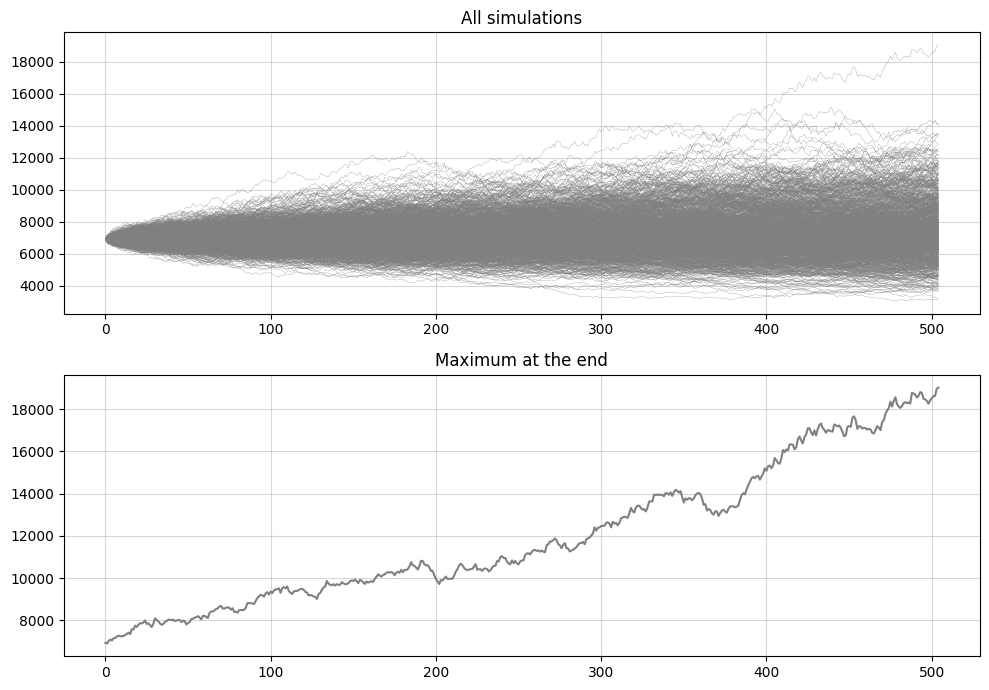

In [8]:
 import matplotlib.pyplot as plt

maximum = max(paths[-1, :])
for i in range(1000):
    if paths[-1, i] == maximum:
        print(i)
        idx = i
plt.figure(figsize=(10, 7))
plt.subplot(2, 1, 1)
plt.plot(paths, linewidth = 0.2, c = 'grey')
plt.title("All simulations")
plt.grid(alpha = 0.5)
plt.subplot(2, 1, 2)
plt.plot(paths[:, idx], c = 'grey')
plt.title("Maximum at the end")
plt.grid(alpha = 0.5)
plt.tight_layout()
plt.show()

In [9]:
num = option1.price_evolv(mat=0.0001)
print(num)

9.316625763540287


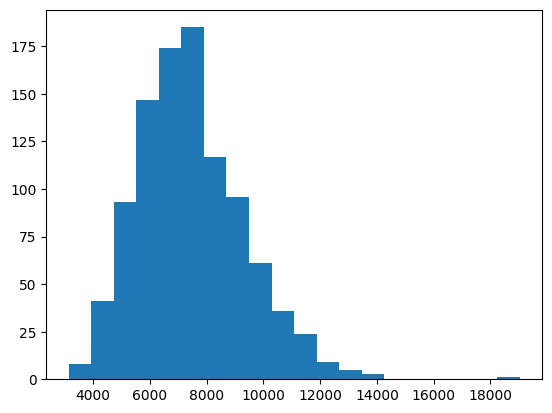

In [10]:
last = paths[-1, :]
plt.hist(last, bins=20)
plt.show()

In [12]:
import numpy as np
from scipy.stats import gaussian_kde
x = np.asarray(last) - parameters.strike
kde = gaussian_kde(x)

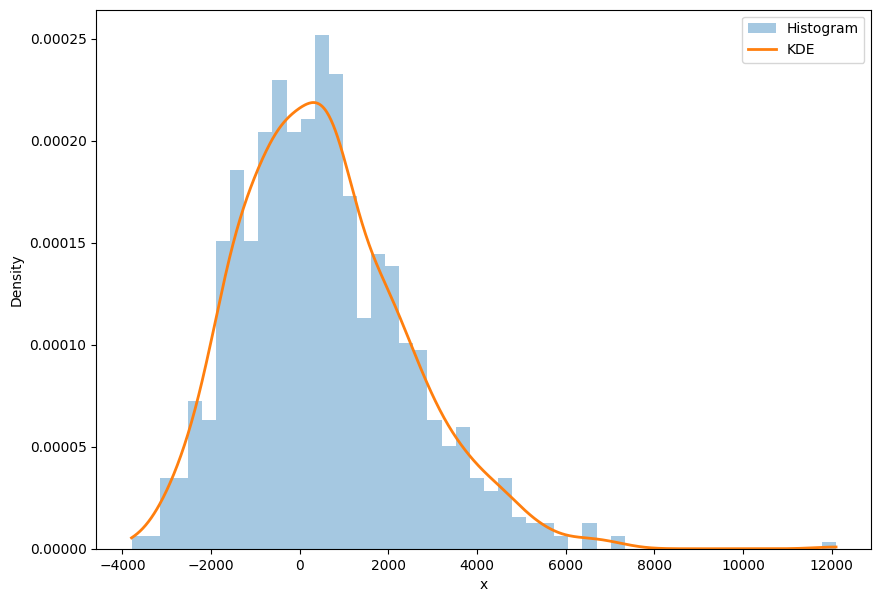

In [13]:
x_grid = np.linspace(x.min(), x.max(), 1000)
pdf = kde(x_grid)

plt.figure(figsize=(10, 7))
plt.hist(x, bins=50, density=True, alpha=0.4, label="Histogram")
plt.plot(x_grid, pdf, lw=2, label="KDE")
plt.legend()
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

In [14]:
from scipy.integrate import cumulative_trapezoid

cdf = cumulative_trapezoid(pdf, x_grid, initial=0)


In [15]:
cdf /= cdf[-1]


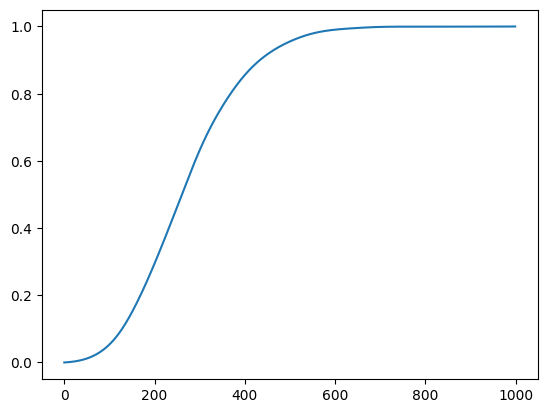

In [16]:
plt.plot(cdf)

In [17]:
def kde_quantile(q, x_grid, cdf):
    return np.interp(q, cdf, x_grid)
q10 = kde_quantile(0.10, x_grid, cdf)
q50 = kde_quantile(0.50, x_grid, cdf)
q90 = kde_quantile(0.90, x_grid, cdf)

print(q10, q50, q90)


-1756.37876577127 353.01169056690713 3102.162125484011


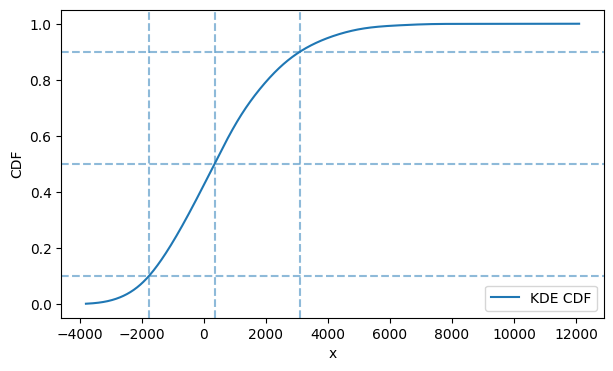

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(x_grid, cdf, label="KDE CDF")

for q in [0.1, 0.5, 0.9]:
    plt.axhline(q, ls="--", alpha=0.5)
    plt.axvline(kde_quantile(q, x_grid, cdf), ls="--", alpha=0.5)

plt.xlabel("x")
plt.ylabel("CDF")
plt.legend()
plt.show()


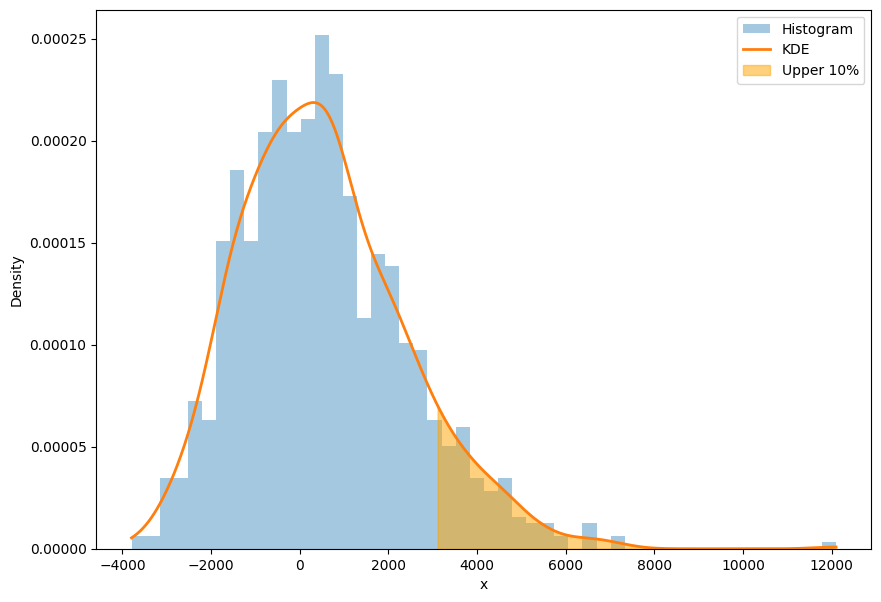

In [19]:
x_grid = np.linspace(x.min(), x.max(), 1000)
pdf = kde(x_grid)

plt.figure(figsize=(10, 7))
plt.hist(x, bins=50, density=True, alpha=0.4, label="Histogram")
plt.plot(x_grid, pdf, lw=2, label="KDE")
plt.fill_between(x_grid[x_grid > q90], pdf[x_grid >q90], color='orange', alpha=0.5, label="Upper 10%")
plt.legend()
plt.xlabel("x")
plt.ylabel("Density")
plt.show()